In [175]:
import sqlite3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, \
    FunctionTransformer


# !pip install ydata-profiling
# from ydata_profiling import ProfileReport


In [176]:
# ── Reusable Helper Functions ──────────────────────────────────────────────

def z_score(df, cols, threshold=3):
    zdf = pd.DataFrame()
    df_clean = df.copy()
    for col in cols:
        mean = df_clean[col].mean()
        std = df_clean[col].std()
        z = (df_clean[col] - mean) / std
        zdf[col + '_Zscore'] = z
        df_clean = df_clean[z.abs() < threshold]
    return zdf, df_clean


def IQR(df, cols):
    df_clean = df.copy()
    for col in cols:
        q1 = df_clean[col].quantile(0.25)
        q3 = df_clean[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        mask = (df_clean[col] < lower) | (df_clean[col] > upper)
        df_clean = df_clean[~mask]
    return df_clean


def winsorization(df, cols, lower=0.05, upper=0.95):
    df_clean = df.copy()
    for col in cols:
        lower_ = df_clean[col].quantile(lower)
        upper_ = df_clean[col].quantile(upper)
        df_clean[col] = df_clean[col].clip(lower=lower_, upper=upper_)
    return df_clean


def iqr_winsorization(df, cols):
    df_cap = df.copy()
    for col in cols:
        q1 = df_cap[col].quantile(0.25)
        q3 = df_cap[col].quantile(0.75)
        iqr = q3 - q1
        lower_limit = q1 - 1.5 * iqr
        upper_limit = q3 + 1.5 * iqr
        df_cap[col] = df_cap[col].clip(lower=lower_limit, upper=upper_limit)
    return df_cap





## 1. Data Understanding & Loading

In [177]:
# Load CSV : Riders
df_riders = pd.read_csv('riders.csv')
print(f'riders.csv shape: {df_riders.shape}')
display(df_riders.head())

riders.csv shape: (1000, 9)


,rider_id,name,age,gender,city,signup_date,total_rides,cancelled_rides,avg_rating
0,R0001,Saanvi Ghosh,56.0,Female,Bengaluru,2020-03-13,64.0,47.0,4.41
1,R0002,Vivaan Das,NaN,Female,Delhi,2022-01-02,266.0,25.0,3.26
2,R0003,Aarav Sharma,NaN,Female,Jaipur,2020-09-07,NaN,NaN,NaN
3,R0004,Ishaan Reddy,NaN,Male,Surat,2019-07-24,345.0,43.0,4.62
4,R0005,Aarav Gupta,NaN,Other,Surat,2023-09-21,454.0,44.0,3.94


In [178]:
# Load JSON : Trips
df_trips = pd.read_json('trips.json')
print(f'trips.json shape: {df_trips.shape}')
display(df_trips.head())

trips.json shape: (1000, 9)


,trip_id,rider_id,zone,distance_km,duration_min,fare_amount,payment_mode,ride_date,surge_flag
0,T00001,R0210,Zone_12,9.25,87.70,292.63,Wallet,2024-08-16,1.0
1,T00002,R0334,Zone_29,24.27,159.36,23.41,Cash,2024-06-15,0.0
2,T00003,R0726,Zone_28,3.08,49.68,401.70,Credit Card,2024-04-18,0.0
3,T00004,R0260,Zone_14,24.73,147.60,481.00,Cash,2024-06-09,1.0
4,T00005,R0446,Zone_14,23.88,145.50,46.87,Wallet,2024-04-12,0.0


In [179]:
# Load SQL : City Zones
conn = sqlite3.connect('city_zones.db')

df_zones = pd.read_sql('SELECT * FROM city_zones', conn)
conn.close()

print(f'city_zones.db shape: {df_zones.shape}')
display(df_zones.head())

city_zones.db shape: (35, 5)


,zone_name,population_density,traffic_index,avg_speed_kmph,zone_type
0,Zone_1,4284.0,2.03,27.7,Residential
1,Zone_2,9862.0,1.99,32.4,Industrial
2,Zone_3,11542.0,1.21,50.8,Residential
3,Zone_4,3516.0,2.39,52.6,Residential
4,Zone_5,3961.0,0.91,38.6,Mixed


In [180]:
# .info() Summary

print('RIDERS INFO: \n')
df_riders.info()

print('\nTRIPS INFO: \n')
df_trips.info()

print('\nCITY ZONES INFO: \n')
df_zones.info()

RIDERS INFO: 

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rider_id         1000 non-null   str    
 1   name             1000 non-null   str    
 2   age              884 non-null    float64
 3   gender           901 non-null    str    
 4   city             881 non-null    str    
 5   signup_date      1000 non-null   str    
 6   total_rides      905 non-null    float64
 7   cancelled_rides  811 non-null    float64
 8   avg_rating       907 non-null    float64
dtypes: float64(4), str(5)
memory usage: 70.4 KB

TRIPS INFO: 

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   trip_id       1000 non-null   str    
 1   rider_id      1000 non-null   str    
 2   zone          1000 non-null   str    
 3   distanc

In [181]:
# Missing Value Counts
print('Missing Values — Riders:')
print(df_riders.isnull().sum(), '\n')

print('Missing Values — Trips:')
print(df_trips.isnull().sum(), '\n')

print('Missing Values — City Zones:')
print(df_zones.isnull().sum())

Missing Values — Riders:
rider_id             0
name                 0
age                116
gender              99
city               119
signup_date          0
total_rides         95
cancelled_rides    189
avg_rating          93
dtype: int64 

Missing Values — Trips:
trip_id           0
rider_id          0
zone              0
distance_km      82
duration_min    105
fare_amount      92
payment_mode     91
ride_date         0
surge_flag       99
dtype: int64 

Missing Values — City Zones:
zone_name             0
population_density    3
traffic_index         1
avg_speed_kmph        3
zone_type             3
dtype: int64


In [182]:
# Duplicate Check
print(f'Rider duplicates    : {df_riders.duplicated().sum()}')
print(f'Trip duplicates     : {df_trips.duplicated().sum()}')
print(f'City zone duplicates: {df_zones.duplicated().sum()}')

Rider duplicates    : 0
Trip duplicates     : 0
City zone duplicates: 0


In [183]:
# Invalid Entry Check

# Age < 10
invalid_age = df_riders[df_riders['age'] < 10]
print(f'Riders with age < 10   : {len(invalid_age)}')

# Negative distance
invalid_dist = df_trips[df_trips['distance_km'] < 0]
print(f'Trips with negative km : {len(invalid_dist)}')

# Negative fare
invalid_fare = df_trips[df_trips['fare_amount'] < 0]
print(f'Trips with negative fare: {len(invalid_fare)}')

# Zero distance but billed
zero_dist_billed = df_trips[(df_trips['distance_km'] == 0) & (df_trips['fare_amount'] > 0)]
print(f'Zero distance but billed: {len(zero_dist_billed)}')

Riders with age < 10   : 0
Trips with negative km : 0
Trips with negative fare: 0
Zero distance but billed: 0



## 2. Data Cleaning

In [184]:
# Working Copies
riders = df_riders.copy()
trips = df_trips.copy()
zones = df_zones.copy()

In [185]:
median = SimpleImputer(strategy='median')
most_freq = SimpleImputer(strategy='most_frequent')
knn = KNNImputer(n_neighbors=5, weights='distance')

In [186]:
# Riders

riders[['gender', 'city']] = most_freq.fit_transform(riders[['gender', 'city']])

riders['age'] = median.fit_transform(riders[['age']])

riders[['total_rides', 'cancelled_rides', 'avg_rating']] = knn.fit_transform(riders[['total_rides', 'cancelled_rides',
                                                                                     'avg_rating']])

print('Riders done:')
print(riders.isnull().sum())

Riders done:
rider_id           0
name               0
age                0
gender             0
city               0
signup_date        0
total_rides        0
cancelled_rides    0
avg_rating         0
dtype: int64


In [187]:
# Trips

trips[['payment_mode']] = most_freq.fit_transform(trips[['payment_mode']])

trips[['distance_km', 'duration_min', 'fare_amount', 'surge_flag']] = knn.fit_transform(
    trips[['distance_km', 'duration_min', 'fare_amount', 'surge_flag']])

print('Trips done:')
print(trips.isnull().sum())

Trips done:
trip_id         0
rider_id        0
zone            0
distance_km     0
duration_min    0
fare_amount     0
payment_mode    0
ride_date       0
surge_flag      0
dtype: int64


In [188]:
# City zones

zones[['zone_type']] = most_freq.fit_transform(zones[['zone_type']])

zones[['population_density', 'traffic_index', 'avg_speed_kmph']] = knn.fit_transform(
    zones[['population_density', 'traffic_index', 'avg_speed_kmph']])

print('City zones done:')
print(zones.isnull().sum())

City zones done:
zone_name             0
population_density    0
traffic_index         0
avg_speed_kmph        0
zone_type             0
dtype: int64


In [189]:
# Convert Date Columns

riders['signup_date'] = pd.to_datetime(riders['signup_date'])
trips['ride_date'] = pd.to_datetime(trips['ride_date'])

print('Riders signup_date dtype :', riders['signup_date'].dtype)
print('Trips  ride_date dtype   :', trips['ride_date'].dtype)

Riders signup_date dtype : datetime64[us]
Trips  ride_date dtype   : datetime64[us]


In [190]:
# Remove Unrealistic Entries

# Negative fare
trips = trips[trips['fare_amount'] >= 0]

# Zero distance but billed
trips = trips[~((trips['distance_km'] == 0) & (trips['fare_amount'] > 0))]

# Age < 10 for riders
riders = riders[riders['age'] >= 10]



## 3. Outlier Handling

In [191]:
# Before Stats
outlier_cols = ['fare_amount', 'distance_km', 'duration_min']
print('Before Outlier Handling:')
display(trips[outlier_cols].describe().round(2))

Before Outlier Handling:


,fare_amount,distance_km,duration_min
count,1000.00,1000.00,1000.00
mean,257.16,13.26,90.67
std,138.45,6.79,49.60
min,10.61,0.52,5.11
25%,139.40,7.64,49.35
50%,264.42,13.83,89.64
75%,374.29,18.58,132.89
max,499.45,25.00,179.53


In [192]:
# Z-Score : fare_amount & distance_km
z_scores_df, trips_z = z_score(trips, ['fare_amount', 'distance_km'], threshold=3)
print(f'Trips after Z-score filtering: {len(trips_z)} (removed {len(trips) - len(trips_z)} rows)')

Trips after Z-score filtering: 1000 (removed 0 rows)


In [193]:
# IQR : duration_min
trips_clean = IQR(trips_z, ['duration_min'])
print(f'Trips after IQR filtering: {len(trips_clean)} (removed {len(trips_z) - len(trips_clean)} rows)')

Trips after IQR filtering: 1000 (removed 0 rows)


In [194]:
# Winsorization : surge fares (extreme fare_amount)
trips_clean = winsorization(trips_clean, ['fare_amount'], lower=0.02, upper=0.98)
print('Winsorization applied on fare_amount.')

Winsorization applied on fare_amount.


After Outlier Handling:


,fare_amount,distance_km,duration_min
count,1000.00,1000.00,1000.00
mean,257.15,13.26,90.67
std,138.04,6.79,49.60
min,19.71,0.52,5.11
25%,139.40,7.64,49.35
50%,264.42,13.83,89.64
75%,374.29,18.58,132.89
max,487.36,25.00,179.53


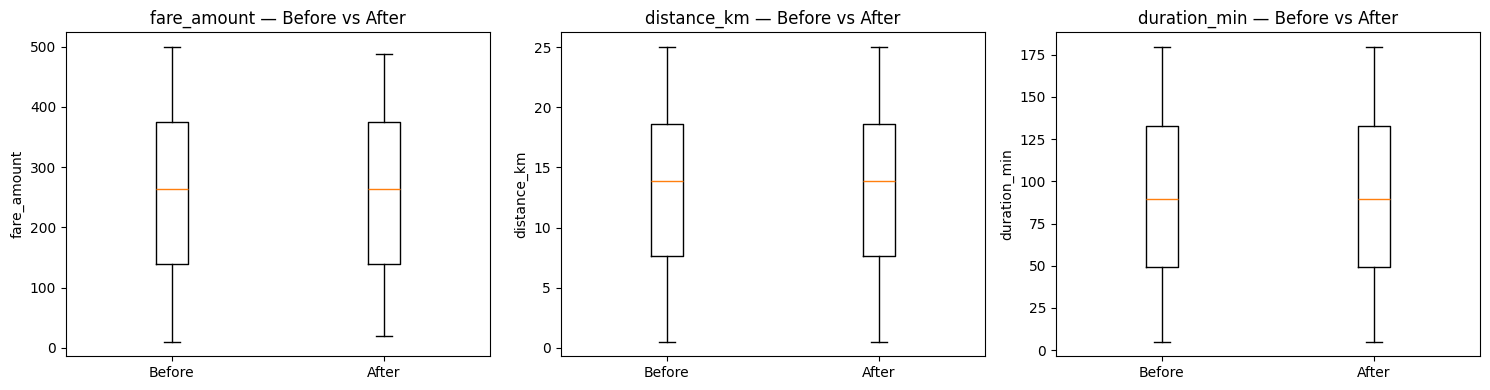

In [195]:
# Before vs After Comparison
print('After Outlier Handling:')
display(trips_clean[outlier_cols].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(outlier_cols):
    axes[i].boxplot([trips[col].dropna(), trips_clean[col].dropna()],
                    tick_labels=['Before', 'After'])
    axes[i].set_title(f'{col} — Before vs After')
    axes[i].set_ylabel(col)
plt.tight_layout()
plt.show()


## 4. Data Transformation

In [196]:
# Datetime → hour, day_of_week, month
trips_clean['hour'] = trips_clean['ride_date'].dt.hour
trips_clean['day_of_week'] = trips_clean['ride_date'].dt.dayofweek
trips_clean['month'] = trips_clean['ride_date'].dt.month

print('Datetime features extracted:')
display(trips_clean[['ride_date', 'hour', 'day_of_week', 'month']].head())

Datetime features extracted:


,ride_date,hour,day_of_week,month
0,2024-08-16,0,4,8
1,2024-06-15,0,5,6
2,2024-04-18,0,3,4
3,2024-06-09,0,6,6
4,2024-04-12,0,4,4


In [197]:
# Label Encode : gender
le = LabelEncoder()
riders['gender_encoded'] = le.fit_transform(riders['gender'])

print('Label Encoding — gender:')
display(riders[['gender', 'gender_encoded']].head())

Label Encoding — gender:


,gender,gender_encoded
0,Female,0
1,Female,0
2,Female,0
3,Male,1
4,Other,2


In [198]:
# One-Hot Encode : ride_payment_mode, zone_name

trips_clean = pd.get_dummies(trips_clean, columns=['payment_mode'], prefix='pm', dtype=int)

print('One-Hot Encoding done:')
display(trips_clean.head())
display(zones.head())

One-Hot Encoding done:


,trip_id,rider_id,zone,distance_km,duration_min,fare_amount,ride_date,surge_flag,hour,day_of_week,month,pm_Cash,pm_Credit Card,pm_UPI,pm_Wallet
0,T00001,R0210,Zone_12,9.25,87.70,292.63,2024-08-16,1.0,0,4,8,0,0,0,1
1,T00002,R0334,Zone_29,24.27,159.36,23.41,2024-06-15,0.0,0,5,6,1,0,0,0
2,T00003,R0726,Zone_28,3.08,49.68,401.70,2024-04-18,0.0,0,3,4,0,1,0,0
3,T00004,R0260,Zone_14,24.73,147.60,481.00,2024-06-09,1.0,0,6,6,1,0,0,0
4,T00005,R0446,Zone_14,23.88,145.50,46.87,2024-04-12,0.0,0,4,4,0,0,0,1


,zone_name,population_density,traffic_index,avg_speed_kmph,zone_type
0,Zone_1,4284.0,2.03,27.7,Residential
1,Zone_2,9862.0,1.99,32.4,Industrial
2,Zone_3,11542.0,1.21,50.8,Residential
3,Zone_4,3516.0,2.39,52.6,Residential
4,Zone_5,3961.0,0.91,38.6,Mixed


In [199]:
# Binning : Customer Ride Frequency (Low / Med / High)
riders['ride_freq_bin'] = pd.cut(
    riders['total_rides'],
    bins=[0, 100, 300, np.inf],
    labels=['Low', 'Med', 'High']
)

print('Ride Frequency Binning:')
print(riders['ride_freq_bin'].value_counts())

Ride Frequency Binning:
ride_freq_bin
Med     433
High    393
Low     173
Name: count, dtype: int64


In [200]:
# Skew Transforms
log = FunctionTransformer(func=np.log1p, inverse_func=np.expm1)

trips_clean[['fare_log', 'distance_log']] = log.fit_transform(trips_clean[['fare_amount', 'distance_km']])

print('Log Transform: ')
display(trips_clean[['fare_log', 'distance_log']].head())

sqrt = FunctionTransformer(func=np.sqrt, inverse_func=np.square)
trips_clean['duration_sqrt'] = sqrt.fit_transform(trips_clean[['duration_min']])

print('Square Root Transform: ')
display(trips_clean[['duration_sqrt']].head())



Log Transform: 


,fare_log,distance_log
0,5.682320,2.327278
1,3.194993,3.229618
2,5.998192,1.406097
3,6.177944,3.247658
4,3.868489,3.214064


Square Root Transform: 


,duration_sqrt
0,9.364828
1,12.623787
2,7.048404
3,12.149074
4,12.062338



## 5.  Feature Scaling

In [201]:
scale_cols = ['fare_amount', 'distance_km', 'duration_min']

# StandardScaler
ss = StandardScaler()

columns = [c + '_std' for c in scale_cols]
trips_clean[columns] = ss.fit_transform(
    trips_clean[scale_cols])

print('Standardization:')
display(trips_clean[columns].head())

mm = MinMaxScaler()

columns = [c + '_minmax' for c in scale_cols]
trips_clean[columns] = mm.fit_transform(
    trips_clean[scale_cols])

print('MinMax Scaling:')
display(trips_clean[columns].head())


Standardization:


,fare_amount_std,distance_km_std,duration_min_std
0,0.257125,-0.590639,-0.059941
1,-1.694142,1.621642,1.385593
2,1.047648,-1.499412,-0.826886
3,1.622403,1.689395,1.148369
4,-1.524107,1.564199,1.106007


MinMax Scaling:


,fare_amount_minmax,distance_km_minmax,duration_min_minmax
0,0.583600,0.356618,0.473512
1,0.007909,0.970180,0.884360
2,0.816831,0.104575,0.255533
3,0.986403,0.988971,0.816936
4,0.058075,0.954248,0.804896



## 6. Feature Construction

In [202]:
# Merge trips + riders for rider-level features
merged = trips_clean.merge(riders, on='rider_id', how='left')
print(f'Merged shape: {merged.shape}')
display(merged.head(3))

Merged shape: (1000, 34)


,trip_id,rider_id,zone,distance_km,duration_min,fare_amount,ride_date,surge_flag,hour,day_of_week,month,pm_Cash,pm_Credit Card,pm_UPI,pm_Wallet,fare_log,distance_log,duration_sqrt,fare_amount_std,distance_km_std,duration_min_std,fare_amount_minmax,distance_km_minmax,duration_min_minmax,name,age,gender,city,signup_date,total_rides,cancelled_rides,avg_rating,gender_encoded,ride_freq_bin
0,T00001,R0210,Zone_12,9.25,87.70,292.63,2024-08-16,1.0,0,4,8,0,0,0,1,5.682320,2.327278,9.364828,0.257125,-0.590639,-0.059941,0.583600,0.356618,0.473512,Arjun Nair,38.0,Male,Chennai,2021-02-01,349.0,11.0,4.58,1,High
1,T00002,R0334,Zone_29,24.27,159.36,23.41,2024-06-15,0.0,0,5,6,1,0,0,0,3.194993,3.229618,12.623787,-1.694142,1.621642,1.385593,0.007909,0.970180,0.884360,Reyansh Singh,25.0,Female,Chennai,2023-12-02,463.0,1.0,3.44,0,High
2,T00003,R0726,Zone_28,3.08,49.68,401.70,2024-04-18,0.0,0,3,4,0,1,0,0,5.998192,1.406097,7.048404,1.047648,-1.499412,-0.826886,0.816831,0.104575,0.255533,Ishaan Reddy,54.0,Other,Hyderabad,2019-07-06,148.0,13.0,4.64,2,Med


In [203]:
# avg_ride_distance : total distance / total trips per rider
rider_stats = merged.groupby('rider_id').agg(
    total_distance=('distance_km', 'sum'),
    total_trips_merged=('trip_id', 'count'),
    total_fare=('fare_amount', 'sum')
).reset_index()

rider_stats['avg_ride_distance'] = rider_stats['total_distance'] / rider_stats['total_trips_merged']
rider_stats['avg_ride_fare'] = rider_stats['total_fare'] / rider_stats['total_trips_merged']

print('avg_ride_distance & avg_ride_fare computed')
display(rider_stats.head())

avg_ride_distance & avg_ride_fare computed


,rider_id,total_distance,total_trips_merged,total_fare,avg_ride_distance,avg_ride_fare
0,R0001,17.650,3,963.30,5.883333,321.100000
1,R0003,40.180,3,698.11,13.393333,232.703333
2,R0004,25.770,2,619.78,12.885000,309.890000
3,R0005,11.160,1,106.97,11.160000,106.970000
4,R0006,44.654,4,882.40,11.163500,220.600000


In [204]:
# is_peak_hour : 1 if hour in [7-9, 18-21] else 0
merged['is_peak_hour'] = merged['hour'].apply(
    lambda h: 1 if (7 <= h <= 9) or (18 <= h <= 21) else 0
)

print('is_peak_hour distribution:')
print(merged['is_peak_hour'].value_counts())

is_peak_hour distribution:
is_peak_hour
0    1000
Name: count, dtype: int64


In [205]:
# days_since_signup : today - signup_date
today = pd.Timestamp(date.today())
merged['days_since_signup'] = (today - merged['signup_date']).dt.days

print('days_since_signup sample:')
display(merged[['rider_id', 'signup_date', 'days_since_signup']].head())

days_since_signup sample:


,rider_id,signup_date,days_since_signup
0,R0210,2021-02-01,1897
1,R0334,2023-12-02,863
2,R0726,2019-07-06,2473
3,R0260,2019-06-07,2502
4,R0446,2021-05-10,1799


In [206]:
# ride_cancellation_rate : cancelled_rides / total_rides
merged['ride_cancellation_rate'] = merged['cancelled_rides'] / merged['total_rides'].replace(0, np.nan)
merged['ride_cancellation_rate'] = merged['ride_cancellation_rate'].fillna(0)

print('ride_cancellation_rate sample:')
display(merged[['rider_id', 'total_rides', 'cancelled_rides', 'ride_cancellation_rate']].head())

ride_cancellation_rate sample:


,rider_id,total_rides,cancelled_rides,ride_cancellation_rate
0,R0210,349.0,11.000000,0.031519
1,R0334,463.0,1.000000,0.002160
2,R0726,148.0,13.000000,0.087838
3,R0260,133.0,19.796157,0.148843
4,R0446,351.0,47.000000,0.133903


In [207]:
# surge_flag : 1 if fare/distance > threshold
fare_per_km = merged['fare_amount'] / merged['distance_km'].replace(0, np.nan)
threshold = fare_per_km.quantile(0.75)

merged['surge_flag'] = (fare_per_km > threshold).astype(int)

print(f'Surge threshold (fare/km) : {threshold:.2f}')
print('surge_flag distribution   :')
print(merged['surge_flag'].value_counts())

Surge threshold (fare/km) : 34.35
surge_flag distribution   :
surge_flag
0    750
1    250
Name: count, dtype: int64


In [208]:
# ─Merge rider_stats back
merged = merged.merge(rider_stats[['rider_id', 'avg_ride_distance', 'avg_ride_fare']], on='rider_id', how='left')
print(f'Final merged shape: {merged.shape}')

Final merged shape: (1000, 39)



## 7. Final Dataset

In [209]:
# Select Final Columns
final_cols = [
    'trip_id', 'rider_id', 'zone',
    'distance_km', 'duration_min', 'fare_amount',
    'ride_date', 'hour', 'day_of_week', 'month',
    'fare_log', 'distance_log', 'duration_sqrt',
    'fare_amount_std', 'distance_km_std', 'duration_min_std',
    'fare_amount_minmax', 'distance_km_minmax', 'duration_min_minmax',
    'is_peak_hour', 'surge_flag',
    'gender_encoded', 'ride_freq_bin',
    'avg_ride_distance', 'avg_ride_fare',
    'days_since_signup', 'ride_cancellation_rate',
    'total_rides', 'cancelled_rides', 'avg_rating',
]

final_df = merged[final_cols].copy()
print(f'Final dataset shape: {final_df.shape}')
display(final_df.head())

Final dataset shape: (1000, 30)


,trip_id,rider_id,zone,distance_km,duration_min,fare_amount,ride_date,hour,day_of_week,month,fare_log,distance_log,duration_sqrt,fare_amount_std,distance_km_std,duration_min_std,fare_amount_minmax,distance_km_minmax,duration_min_minmax,is_peak_hour,surge_flag,gender_encoded,ride_freq_bin,avg_ride_distance,avg_ride_fare,days_since_signup,ride_cancellation_rate,total_rides,cancelled_rides,avg_rating
0,T00001,R0210,Zone_12,9.25,87.70,292.63,2024-08-16,0,4,8,5.682320,2.327278,9.364828,0.257125,-0.590639,-0.059941,0.583600,0.356618,0.473512,0,0,1,High,9.250000,292.630000,1897,0.031519,349.0,11.000000,4.58
1,T00002,R0334,Zone_29,24.27,159.36,23.41,2024-06-15,0,5,6,3.194993,3.229618,12.623787,-1.694142,1.621642,1.385593,0.007909,0.970180,0.884360,0,0,0,High,24.270000,23.410000,863,0.002160,463.0,1.000000,3.44
2,T00003,R0726,Zone_28,3.08,49.68,401.70,2024-04-18,0,3,4,5.998192,1.406097,7.048404,1.047648,-1.499412,-0.826886,0.816831,0.104575,0.255533,0,1,2,Med,10.055667,241.432667,2473,0.087838,148.0,13.000000,4.64
3,T00004,R0260,Zone_14,24.73,147.60,481.00,2024-06-09,0,6,6,6.177944,3.247658,12.149074,1.622403,1.689395,1.148369,0.986403,0.988971,0.816936,0,0,0,Med,23.315000,484.085000,2502,0.148843,133.0,19.796157,3.79
4,T00005,R0446,Zone_14,23.88,145.50,46.87,2024-04-12,0,4,4,3.868489,3.214064,12.062338,-1.524107,1.564199,1.106007,0.058075,0.954248,0.804896,0,0,0,High,23.880000,46.870000,1799,0.133903,351.0,47.000000,4.82


In [210]:
# Export
final_df.to_csv('final_prepared_rides_dataset.csv', index=False)
print('Exported > final_prepared_rides_dataset.csv')

Exported > final_prepared_rides_dataset.csv



## Bonus — EDA Visualizations

C:\Users\desai\AppData\Local\Temp\ipykernel_19128\1449214755.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No Surge', 'Surge'])
C:\Users\desai\AppData\Local\Temp\ipykernel_19128\1449214755.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No Surge', 'Surge'])


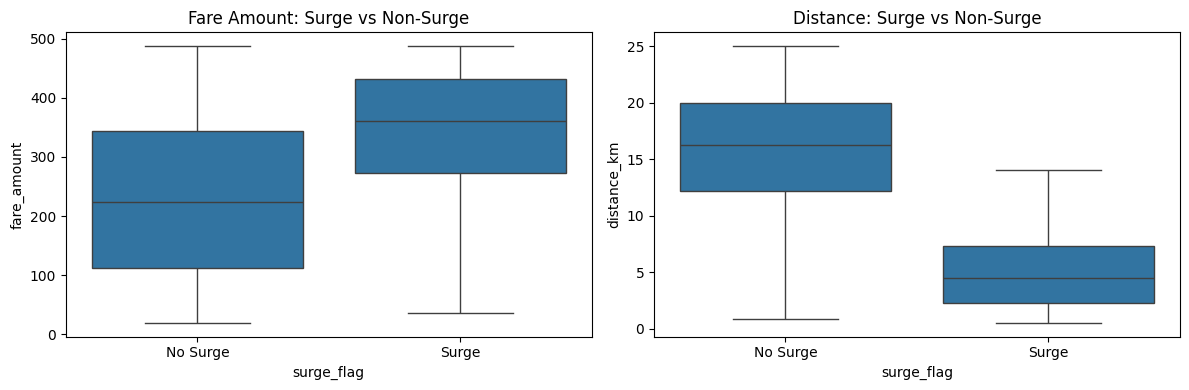

In [211]:
# Surge vs No-Surge Trip Patterns
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=merged, x='surge_flag', y='fare_amount', ax=axes[0])
axes[0].set_title('Fare Amount: Surge vs Non-Surge')
axes[0].set_xticklabels(['No Surge', 'Surge'])

sns.boxplot(data=merged, x='surge_flag', y='distance_km', ax=axes[1])
axes[1].set_title('Distance: Surge vs Non-Surge')
axes[1].set_xticklabels(['No Surge', 'Surge'])

plt.tight_layout()
plt.show()

In [212]:
# Optional: YData Profiling EDA Report
# !pip install ydata-profiling
# from ydata_profiling import ProfileReport
# profile = ProfileReport(final_df, title='Ride Data EDA Report', explorative=True)
# profile.to_file('eda_report.html')
# print('EDA report saved > eda_report.html')